# **Libraries**

In [1]:
import numpy as np
import os
import zipfile
import cv2 as cv
import matplotlib.pyplot as plt
#from google.colab import drive
import gdown
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split
import tensorflow_hub as hub
import tensorflow as tf

2025-08-14 08:37:36.573678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755160656.764357      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755160656.815051      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
plt.style.use("dark_background")

In [3]:
#drive.mount("/content/drive")
drive_path="https://drive.google.com/file/d/1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-/view?usp=drive_link"
file_id = "1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "dataset.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-
From (redirected): https://drive.google.com/uc?id=1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-&confirm=t&uuid=7a09e58a-ac2f-4154-8913-bd9f9f77f072
To: /kaggle/working/dataset.zip
100%|██████████| 1.78G/1.78G [00:14<00:00, 122MB/s] 


'dataset.zip'

In [4]:
#Path in drive
#dataset_zip_path='/content/drive/MyDrive/VideoClassification/Shop DataSet.zip'
#zipfile_obj=zipfile.ZipFile(dataset_zip_path,'r')
#zipfile_obj.extractall('/content')
#zipfile_obj.close()
# Path in drive
dataset_zip_path='/kaggle/working/dataset.zip'
zipfile_obj=zipfile.ZipFile(dataset_zip_path,'r')
zipfile_obj.extractall('/kaggle/working/dataset')
zipfile_obj.close()

In [5]:
dataset_path="/kaggle/working/dataset/Shop DataSet"

#dataset_path="/content/Shop DataSet"
#dataset_path = "C:/Users/nadak/Downloads/Shop DataSet"

In [6]:
FRAMES =16
WIDTH=128
HEIGHT=128

# **Dataset overview**

In [7]:
class_names = os.listdir(dataset_path)
num_classes=len(class_names)
class_paths =[os.path.join(dataset_path,class_path) for class_path in class_names ]
class_sample_counts =[len(os.listdir(class_folder)) for class_folder in class_paths  ]

## **Class Distribution Visualization**

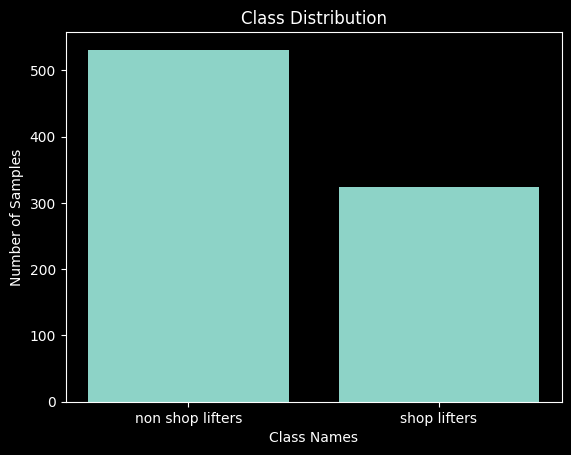

In [8]:
plt.bar(class_names, class_sample_counts)
plt.xlabel("Class Names")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

## **Frames Distribution Visualization**

In [9]:
def get_frames_distribution(class_path):
  video_paths=[os.path.join(class_path,video_name) for video_name in os.listdir(class_path)]
  frames=[]
  for video_path in video_paths:
    cap=cv.VideoCapture(video_path)
    if cap.isOpened():
      frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
      frames.append(frame_count)
  return frames

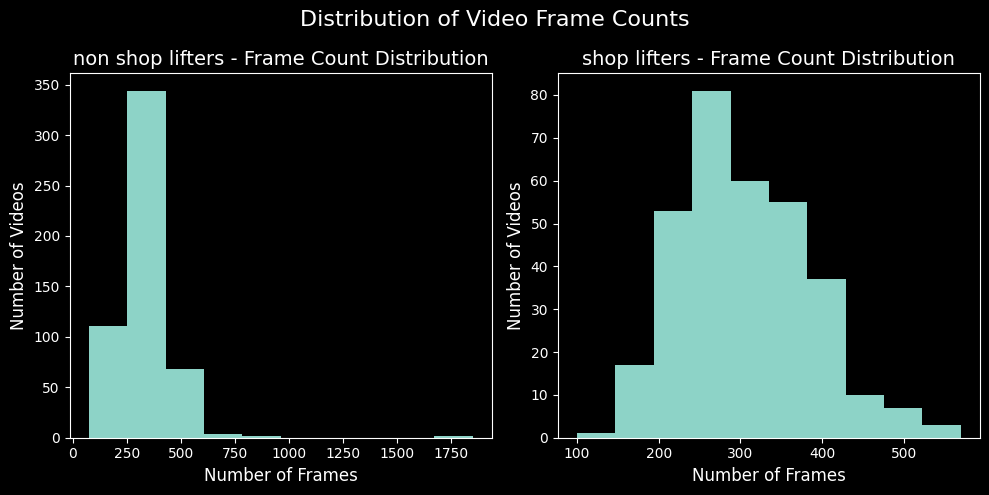

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for index in range(num_classes):
    frames = get_frames_distribution(class_paths[index])
    axes[index].hist(frames, bins=10)
    axes[index].set_xlabel("Number of Frames", fontsize=12)
    axes[index].set_ylabel("Number of Videos", fontsize=12)
    axes[index].set_title(f"{class_names[index]} - Frame Count Distribution", fontsize=14)

fig.suptitle("Distribution of Video Frame Counts", fontsize=16)
plt.tight_layout()
plt.show()

# **Preprocessing**

In [11]:
def preprocessing_video(video_path):
  cap=cv.VideoCapture(video_path)
  if not cap.isOpened():
    print("can not open this video")
    return
  frames=[]
  video_frame_count=int(cap.get(cv.CAP_PROP_FRAME_COUNT))
  skip_frames_window=max(int(video_frame_count/FRAMES ),1)
  for frame_counter in range(FRAMES ):
    cap.set(cv.CAP_PROP_POS_FRAMES,frame_counter*skip_frames_window)
    ret,frame=cap.read()
    if not ret:
      break
    # Convert BGR to RGB
    frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    # Resize Frames
    frame_resized=cv.resize(frame_rgb,(WIDTH,HEIGHT))
    # Normalize RGB
    frame_normalize = frame_resized.astype(np.float32) / 255.0
    frames.append(frame_normalize)
  cap.release()
  return np.array(frames)

In [12]:
features=[]
labels=[]

In [13]:
for class_index in range(num_classes):
  class_video_paths=[os.path.join(class_paths[class_index],video_name) for video_name in os.listdir(class_paths[class_index])]
  for video_path in class_video_paths:
    labels.append(class_index)
    frames=preprocessing_video(video_path)
    features.append(frames)

In [14]:
features=np.array(features)
labels=np.array(labels)

In [15]:
x_train,x_test,y_train,y_test=train_test_split(features,labels,test_size=0.3,shuffle=True,random_state=42)

In [16]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((598, 16, 128, 128, 3), (257, 16, 128, 128, 3), (598,), (257,))

In [17]:
x_val,x_test,y_val,y_test=train_test_split(x_test,y_test,test_size=0.5,shuffle=True,random_state=42)

In [18]:
x_val.shape,x_test.shape,y_val.shape,y_test.shape

((128, 16, 128, 128, 3), (129, 16, 128, 128, 3), (128,), (129,))

# Pretrained

In [30]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# ======================
# CONFIG
# ======================
NUM_FRAMES = 16        # Number of frames per video
HEIGHT, WIDTH = 128, 128  # Frame size
CHANNELS = 3
NUM_CLASSES = 1        # Binary classification

# ======================
# CNN FEATURE EXTRACTOR
# ======================
cnn_base = EfficientNetB0(
    include_top=False,
    weights='imagenet',   # pretrained on ImageNet
    input_shape=(HEIGHT, WIDTH, CHANNELS)
)
cnn_base.trainable = False  # freeze CNN

# ======================
# INPUT: sequence of frames
# ======================
inputs = layers.Input(shape=(NUM_FRAMES, HEIGHT, WIDTH, CHANNELS))

# Apply CNN to each frame
x = layers.TimeDistributed(cnn_base)(inputs)
x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

# ======================
# LSTM LAYER
# ======================
x = layers.LSTM(128, return_sequences=False)(x)

# ======================
# OUTPUT LAYER
# ======================
outputs = layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

# ======================
# BUILD MODEL
# ======================
model = models.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 16, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 16, 4, 4, 1280) │     4,049,571 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 16, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,771,108 (18.20 MB)

 Trainable params: 721,537 (2.75 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [31]:
for layer in cnn_base.layers[-100:]:
    layer.trainable=True


In [32]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [33]:
history=model.fit(x_train,y_train,validation_data=(x_val,y_val),epochs=20)

Epoch 1/20


E0000 00:00:1755163941.938418      36 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/time_distributed_4_1/block2b_drop_31/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


19/19 ━━━━━━━━━━━━━━━━━━━━ 366s 3s/step - accuracy: 0.6124 - loss: 0.7126 - val_accuracy: 0.3125 - val_loss: 0.9538
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 791ms/step - accuracy: 0.7137 - loss: 0.5523 - val_accuracy: 0.6875 - val_loss: 1.5213
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 792ms/step - accuracy: 0.8588 - loss: 0.3145 - val_accuracy: 0.6875 - val_loss: 1.7839
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 770ms/step - accuracy: 0.8688 - loss: 0.3166 - val_accuracy: 0.8984 - val_loss: 0.2794
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 761ms/step - accuracy: 0.8924 - loss: 0.2505 - val_accuracy: 0.5391 - val_loss: 0.9982
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 758ms/step - accuracy: 0.9464 - loss: 0.1385 - val_accuracy: 0.6875 - val_loss: 1.1306
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 767ms/step - accuracy: 0.9201 - loss: 0.2252 - val_accuracy: 0.6875 - val_loss: 1.8893
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 770ms/step - accuracy: 0.9482 - loss: 0.1506 - val_accuracy: 0.3125 

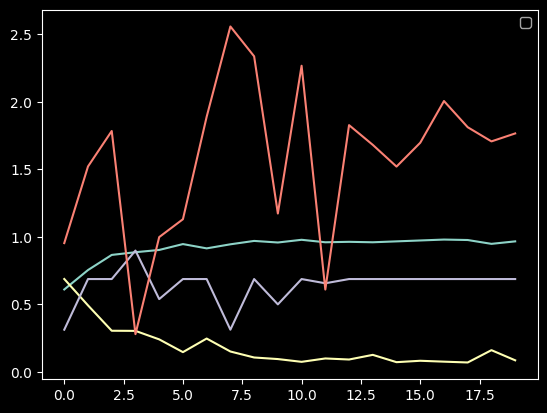

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
plt.plot(pd.DataFrame(history.history))
plt.legend()
plt.show()

In [47]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

# ======================
# CONFIG
# ======================
NUM_FRAMES = 16        # Number of frames per video
HEIGHT, WIDTH = 128, 128  # Frame size
CHANNELS = 3
NUM_CLASSES = 1        # Binary classification

# ======================
# CNN FEATURE EXTRACTOR
# ======================
cnn_base = DenseNet121(
    include_top=False,
    weights='imagenet',   # pretrained on ImageNet
    input_shape=(HEIGHT, WIDTH, CHANNELS)
)
cnn_base.trainable = False  # freeze CNN (can unfreeze last layers if desired)

# ======================
# INPUT: sequence of frames
# ======================
inputs = layers.Input(shape=(NUM_FRAMES, HEIGHT, WIDTH, CHANNELS))

# Apply CNN to each frame
x = layers.TimeDistributed(cnn_base)(inputs)
x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)

# ======================
# LSTM LAYER
# ======================
x = layers.LSTM(128, return_sequences=False)(x)

# ======================
# OUTPUT LAYER
# ======================
outputs = layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

# ======================
# BUILD MODEL
# ======================
model = models.Model(inputs=inputs, outputs=outputs)

# ======================
# COMPILE MODEL
# ======================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 16, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 16, 4, 4, 1024) │     7,037,504 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 16, 1024)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,627,969 (29.10 MB)

 Trainable params: 590,465 (2.25 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [45]:
#for layer in cnn_base.layers:
 #   layer.trainable=True


In [48]:
history=model.fit(x_train,y_train,validation_data=(x_val,y_val),epochs=20)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 401s 6s/step - accuracy: 0.5876 - loss: 0.6466 - val_accuracy: 0.8516 - val_loss: 0.5121
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8659 - loss: 0.4804 - val_accuracy: 0.8828 - val_loss: 0.3914
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8854 - loss: 0.3639 - val_accuracy: 0.9062 - val_loss: 0.2917
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9278 - loss: 0.2526 - val_accuracy: 0.9453 - val_loss: 0.2477
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9599 - loss: 0.1687 - val_accuracy: 0.9531 - val_loss: 0.1747
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9845 - loss: 0.1137 - val_accuracy: 0.9453 - val_loss: 0.1342
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9830 - loss: 0.0840 - val_accuracy: 0.9453 - val_loss: 0.1106
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9741 - loss: 0.0871 - val_accuracy: 0.9688 - val_loss

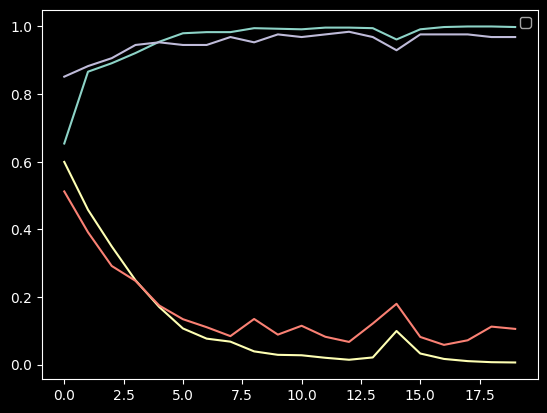

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
plt.plot(pd.DataFrame(history.history))
plt.legend()
plt.show()

In [51]:
model.evaluate(x_test,y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 123s 918ms/step - accuracy: 0.9862 - loss: 0.0225


[0.025580313056707382, 0.9844961166381836]

In [52]:
y_pred=model.predict(x_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 186s 23s/step


In [53]:
y_pred=y_pred>0.5

In [55]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        79
           1       0.96      1.00      0.98        50

    accuracy                           0.98       129
   macro avg       0.98      0.99      0.98       129
weighted avg       0.99      0.98      0.98       129

